-----
# Vectorising Data with TF-IDF
------

## Notebook Summary

This notebook focuses on tokenising the dataset and performing topic modelling using Latent Dirichlet Allocation (LDA) to uncover the context of emails in the dataset. For efficiency, I have used only 15,000 rows.

The notebook is divided into the following stages:

1. **Data Loading:** Load the cleaned data from the data folder.

2. **Preparing Text:** Preprocess the text for tokenisation, handling stopwords, and using SpaCy to remove irrelevant words.

3. **Vectorising Text:** Apply TF-IDF with a custom tokeniser to convert text into numerical form.

4. **Topic Modelling with LDA:** Group the data into topics and analyse groupings.


## Set Up
----

In [114]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import re
import string
import spacy
import matplotlib.pyplot as plt

## Data Loading
----

In [115]:
emails_df = pd.read_csv('../../data/cleaned_emails.csv', index_col= 0)

In [116]:
# working with subset of data first to assess results
email_subset_df = emails_df[:15000].copy()

## Preparing Text
---

In [117]:
# Combining subject and body to better understand context of emails
email_subset_df['all_text'] = email_subset_df['cleaned_subject'] + ' ' + email_subset_df['cleaned_body']

### Define StopWords

In [118]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/simybasra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [119]:
eng_stop_words = stopwords.words('english')

In [120]:
# since punc was removed in cleaning, I need to do the same for stop words
# using regexp to remove all characters which are not words or whitespaces (punctuation)
processed_stop_words = [re.sub(r'[^\w\s]', '', word) for word in eng_stop_words]

In [121]:
# custom list of stop words, all are in lower case since in tokeniser I will force case to be lower
greetings = ['hello', 'hi', 'dear', 'regards', 'thanks', 'thank', 'sincerely', 'best', 'regard', 'regarding']
email_jargon = ['re', 'fw', 'cc','forwarded','forward','original message','original', 'bcc','x', 'subject', 'message', 'email', 'mail','intend','recipient']
std_phrases= ['follow', 'link', 'also', 'please', 'let', 'know', 'kindly', 'attached', 'find', 'below', 'attach','pm', 'am','like','see','time','us', 'rights', 'said', 'reserved']
std_words = ['go', 'get', 'take', 'come', 'think', 'make', 'enron', 'going','look','may','image', 'would', 'could' ,'fax', 'name', 'one','want','call', 'use','new', 'need', 'meet', 'work','receives', 'receiving','back']
irrelevant_words = [ 'phone', 'long', 'term', 'good', 'web', 'site', 'feel', 'free', 'questions', 'contact' ,'concern', 'put','together', 'im','sure','last','night', 'soon', 'possible','third','parties','hope', 'well', 'even', 'though','request']

custom_stop_words = greetings + email_jargon  + std_phrases + std_words + irrelevant_words

# adding all custom stop words to existing list 
processed_stop_words.extend(custom_stop_words)

----
**Comment:**

Stop word removal to occur in tokeniser for TF-IDF (below)

### Removing Employee Names, Dates and Organisations

In [122]:
# load the pre-trained spaCy model for NER
nlp = spacy.load('en_core_web_sm')

def remove_names(text):
    # ensuring all text is of type string
    text = str(text)
    # using model to process email text (subject + body)
    doc = nlp(text)
    # need to reverse order in which entities are removed to avoid disrupting order of text
    #  important as otherwise model will not recognise other entities to be removed
    for e in reversed(doc.ents):
        # to remove words where entity is PERSON, ORG or DATE
        if e.label_ in ['PERSON', 'ORG', 'DATE']: 
            # remove the entity by slicing the text: 
            #   keep the part before the entity, skip the entity itself and keep the part after it
            text = text[:e.start_char] + text[e.start_char + len(e.text):]

    return text


In [123]:
email_subset_df['all_text'] = email_subset_df['all_text'].apply(remove_names)

### Prepare Tokeniser

In [124]:
# instantiate stemmer to be used in tokeniser
stemmer = nltk.stem.PorterStemmer()

In [125]:
# building a bespoke tokeniser
def my_tokenizer(email):
    
    email = email.lower()
    
    # to remove numbers
    email = re.sub('[0-9]','',email)

    # splitting each sentence by space into words
    listofwords = email.split(' ')
    listofstemmed_words = []
    
    for word in listofwords:  
        # filtering out stopwords and any tokens that are just empty strings
        if (word not in processed_stop_words) and (word != ''):
            # stem words to cut words to the base 
            stemmed_word = stemmer.stem(word)
            listofstemmed_words.append(stemmed_word)

    return listofstemmed_words

## Vectorising Text
----

In [126]:
# instantiate tf-idf vecotriser
my_vectoriser = TfidfVectorizer(max_features=800,
                               min_df = 5,
                               tokenizer= my_tokenizer, # setting tokenizer to my bespoke tokenizer
                               ngram_range=(2,2) # bigrams only
                               )

In [127]:
# tokenise text
text_tranform = my_vectoriser.fit_transform(email_subset_df['all_text'])

/Users/simybasra/anaconda3/envs/email_genie/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [128]:
# create df of results where tokens are columns
email_token_df = pd.DataFrame(columns= my_vectoriser.get_feature_names_out(), data= text_tranform.toarray(), index=email_subset_df.index)

## Insights
------

- most important terms, word clouds, words highest score and document similarity.


In [129]:
# summing counts of tokens down the columns
token_count = text_tranform.toarray().sum(axis=0)

In [130]:
# dataframe of top 20 most frequently occurring words in the dataset (15_000 rows)
token_freq = pd.DataFrame(
    {'count': token_count},
    index=my_vectoriser.get_feature_names_out()
).sort_values('count', ascending=False)

In [131]:
token_freq.head(20)

,count
busi unit,153.499861
natur ga,143.808586
risk manag,138.116333
vice presid,88.901381
north america,88.200005
expens report,88.189425
meet discuss,85.469435
keep post,81.179582
staff meet,79.737921
houston texa,78.267420


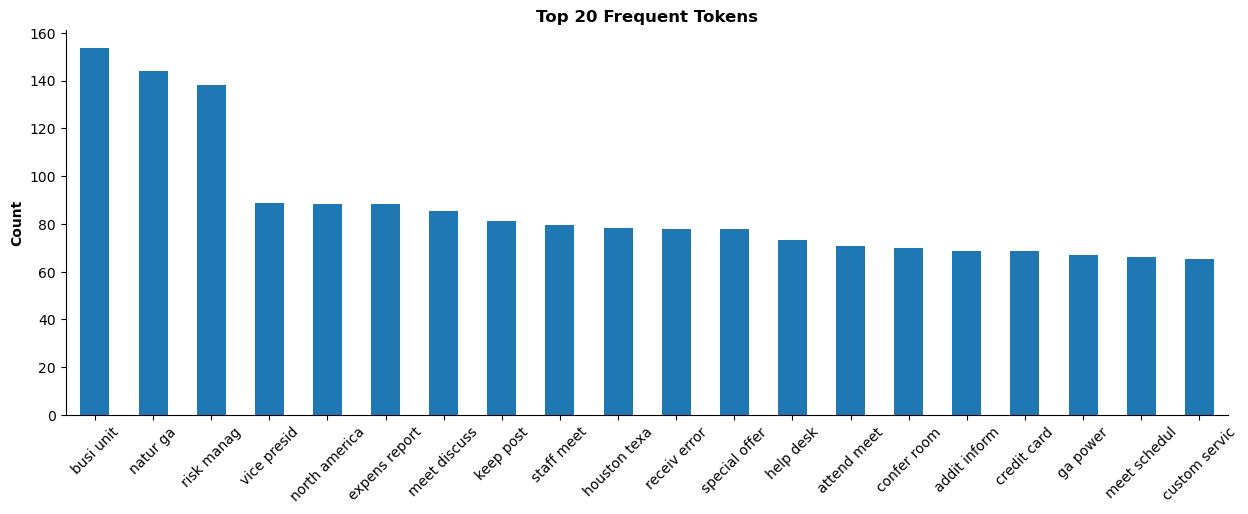

In [140]:
# plot top 20 frequent tokens in dataset (15_000 rows)
token_freq.head(20).plot(kind='bar', figsize=(15, 5), legend=False)
plt.title('Top 20 Frequent Tokens', fontweight = 'bold')
plt.ylabel('Count', fontweight = 'bold')
plt.xticks(rotation=45)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

----
**Comment:**

Above bigrams highlight the key themes in the Enron dataset, there is a clear foucs on business ops and customer service. 

**Key Insights:**

- *Business and management terms:* Bigrams like 'busi unit', 'risk manag', 'natur ga' and, 'vice presid' reflect the business context of the emails.

- *internal communications:* Phrases such as 'expens report', 'staff meet' and 'help desk' suggest communication between employees and support-related tasks.

- *Locations*: 'houston texa' and 'north america' could indicate company's headquarters or vendor locatrions or even possible addresses that are included in email footers.

I still think there is a some noise remaining in the results.

Although I spent some time refining the results, I decided not to dwell too long on this step since the focus is on high-level insights at this stage.

The noise also suggests that more complex vectorisation methods may be necessary for better capturing the context. As a next step, I plan to explore word embeddings.


## Topic Modelling with LDA
----

In [133]:
from sklearn.decomposition import LatentDirichletAllocation

# fit the LDA topic model
lda = LatentDirichletAllocation(
    n_components=4, # number of topics
    max_iter=30, # number of iterations of fitting the model
    random_state=1,
    verbose=1
)

# fit lda model to the tokenised text
lda.fit(text_tranform)

iteration: 1 of max_iter: 30
iteration: 2 of max_iter: 30
iteration: 3 of max_iter: 30
iteration: 4 of max_iter: 30
iteration: 5 of max_iter: 30
iteration: 6 of max_iter: 30
iteration: 7 of max_iter: 30
iteration: 8 of max_iter: 30
iteration: 9 of max_iter: 30
iteration: 10 of max_iter: 30
iteration: 11 of max_iter: 30
iteration: 12 of max_iter: 30
iteration: 13 of max_iter: 30
iteration: 14 of max_iter: 30
iteration: 15 of max_iter: 30
iteration: 16 of max_iter: 30
iteration: 17 of max_iter: 30
iteration: 18 of max_iter: 30
iteration: 19 of max_iter: 30
iteration: 20 of max_iter: 30
iteration: 21 of max_iter: 30
iteration: 22 of max_iter: 30
iteration: 23 of max_iter: 30
iteration: 24 of max_iter: 30
iteration: 25 of max_iter: 30
iteration: 26 of max_iter: 30
iteration: 27 of max_iter: 30
iteration: 28 of max_iter: 30
iteration: 29 of max_iter: 30
iteration: 30 of max_iter: 30


LatentDirichletAllocation(max_iter=30, n_components=4, random_state=1,
                          verbose=1)

In [134]:
tokens = my_vectoriser.get_feature_names_out()

# looping thorugh all topics lda has found
for i, topic in enumerate(lda.components_):
    # get top 10 tokens for each topic, these tokens are those most represntative of the topic
    topic_words = " ".join([tokens[j] for j in topic.argsort()[: -11: -1]])
    print(f"Topic #{i} words: {topic_words}")

Topic #0 words: risk manag vice presid staff meet attend meet meet held busi unit help desk team member plan attend act upon
Topic #1 words: natur ga busi unit keep post receiv error custom servic anyon els houston tx longer receiv ga market someon els
Topic #2 words: houston texa addit inform north america anyth els unit state market particip power market avail view strictli prohibit provid inform
Topic #3 words: expens report meet discuss credit card happi hour agent updat set meet san antonio th floor mail list schedul meet


----
**Comment:**

The topics seem fairly defined in terms of what they represent:

**Topic 0** focuses on management, business operations, and meetings inclusing references to  vice president, staff meetings, and planning.

**Topic 1** centred around the natural gas (ENRON was an energy company) and customer service, includes reference business units, market updates, and communication within teams regarding errors and service.

**Topic 2** related to the energy/power market, compliance, and information sharing. It includes terms like North America, United States, and power market participation, suggesting a focus on the energy market.

**Topic 3** focuses on expense reports, meetings, and corporate events. It includes mentions of credit cards, happy hours, and meetings, indicating a mix of corporate and informal employee socials. There are also references to San Antonio, this could be an office location.

Overall, the topic modelling performed better than I expected, with topics reflecting common themes in work emails. There is still some room for improvement and further refinement to make the results better. However, I think its best to move to word embeddings and perform LDA on embeddings.

## Summary
---

There are some limitations to TF-IDF with this dataset, I think this is due to the high level of noise in email data. The topics found fit within general business day-to-day operations such as but think further refinement is needed before I move to clustering. The next step is to repeat this process using word embeddings to vectorise the email data to see if this produces better results and deeper understanding of context of emails.